In [1]:
import polars as pl
import seaborn as sns
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Polygon, FancyArrowPatch
import matplotlib.patheffects as pe

from modules.design import bc_palette, b_order, b_cat, set_yticks, set_frame, set_hatch

mpl.rcParams['font.family'] = 'Liberation Serif'




In [2]:
bc_translation = {
    "jerryscript": "JerryScript",
    "micropython": "MicroPython",
    "lua": "Lua",
    "wamr": "WAMR",
    "wamr-fast": "WAMR (fast)",
    "micro-bpf": "µBPF",
    "native": "Native"
}


def update_env(df: pl.DataFrame):
    return df.with_columns(
        environment=pl.col("environment").map_elements(lambda e: bc_translation.get(e, e)),
    )


def check_completeness(df: pl.DataFrame):
    difference = set(df["environment"].unique().to_list()).symmetric_difference(bc_palette.keys())
    if difference:
        raise ValueError(f"Difference: {difference}")

def check_correctness(df: pl.DataFrame):
    if not df.select(pl.col("correct").all()).item(0,0):
        raise ValueError("Correctness check failed")


# Runtime

In [3]:
board_file = "../data/runtime/bench_runtime.csv"
benchmark_df = pl.read_csv(board_file)
benchmark_df = benchmark_df.with_columns(benchmark=pl.col("benchmark").str.replace("nettle-sha256", "sha256"))
benchmark_df = update_env(benchmark_df)
check_correctness(benchmark_df)
check_completeness(benchmark_df)

tud_benchmarks = set(b_order)

US_TO_MS = 1 / 1_000

benchmark_df = ((
    benchmark_df.lazy()
    .with_columns(
        load_program_ms=pl.col("load_program_us") * US_TO_MS,
        init_runtime_ms=pl.col("init_runtime_us") * US_TO_MS,
        execution_time_ms=pl.col("execution_time_us") * US_TO_MS,
    )
    .group_by(["environment", "benchmark"])
    .agg(
        load=pl.col("init_runtime_ms") + pl.col("load_program_ms"),
        exec=pl.col("execution_time_ms"),
    )
    .with_columns(
        total=pl.col("load") + pl.col("exec"),
        load_avg=pl.col("load").list.mean(),
        exec_avg=pl.col("exec").list.mean(),
    )
    .with_columns(
        total_avg=pl.col("total").list.mean(),
    )
    .with_columns(
        exec_rel=pl.col("exec_avg")
            / pl.col("exec_avg")
                .filter(pl.col("environment") == "Native")
                .first()
                .over("benchmark"),
        total_rel=pl.col("total_avg")
            / pl.col("total_avg")
                .filter(pl.col("environment") == "Native")
                .first()
                .over("benchmark"),
        load_fraction=pl.col("load_avg") / pl.col("total_avg"),
    )
    .collect()
    )
    .sort(pl.col("benchmark").cast(pl.Enum(b_order))))


# Run Time Stats

In [4]:
stats_df = (
    benchmark_df.group_by("environment")
    .agg(
        (pl.col("exec_rel").max()).alias("Highest Slowdown (Execution Time)"),
        (pl.col("benchmark").sort_by("exec_rel", descending=True).first()).alias("Worst Benchmark (Execution Time)"),
        (pl.col("exec_rel").min()).alias("Lowest Slowdown (Execution Time)"),
        (pl.col("benchmark").sort_by("exec_rel", descending=False).first()).alias("Best Benchmark (Execution Time)"),
        (pl.col("exec_rel").mean()).alias("Mean Slowdown (Execution Time)"),
        (pl.col("total_rel").max()).alias("Highest Slowdown"),
        (pl.col("benchmark").sort_by("total_rel", descending=True).first()).alias("Worst Benchmark"),
        (pl.col("total_rel").min()).alias("Lowest Slowdown"),
        (pl.col("benchmark").sort_by("total_rel", descending=False).first()).alias("Best Benchmark"),
        (pl.col("total_rel").mean()).alias("Mean Slowdown"),
    )
)

stats_df.show(limit=None)

environment,Highest Slowdown (Execution Time),Worst Benchmark (Execution Time),Lowest Slowdown (Execution Time),Best Benchmark (Execution Time),Mean Slowdown (Execution Time),Highest Slowdown,Worst Benchmark,Lowest Slowdown,Best Benchmark,Mean Slowdown
str,f64,str,f64,str,f64,f64,str,f64,str,f64
"""Lua""",273.482828,"""slre""",33.138823,"""xgboost""",127.034503,330.621747,"""slre""",61.126929,"""xgboost""",171.123824
"""WAMR (fast)""",38.409168,"""ud""",10.592899,"""statemate""",27.566542,233.121614,"""nsichneu""",17.168657,"""xgboost""",55.305437
"""Native""",1.0,"""mont64""",1.0,"""mont64""",1.0,1.0,"""mont64""",1.0,"""mont64""",1.0
"""MicroPython""",2478.215992,"""sha256""",73.832743,"""xgboost""",693.552948,2799.330009,"""sha256""",152.503151,"""huffbench""",1000.789187
"""µBPF""",229.918585,"""tarfind""",54.192325,"""mont64""",122.30355,230.075573,"""tarfind""",54.513742,"""mont64""",123.658602
"""JerryScript""",2439.817357,"""sha256""",111.365539,"""xgboost""",718.605747,2502.218133,"""sha256""",154.909059,"""xgboost""",808.075324
"""WAMR""",107.554335,"""nsichneu""",28.305824,"""statemate""",70.403051,165.641895,"""nsichneu""",31.759374,"""statemate""",78.424634


In [5]:
tmp_df = benchmark_df.select(pl.col("environment"), pl.col("benchmark"), load_std=pl.col("load").list.std(), load_mean=pl.col("load").list.mean(), exec_std=pl.col("exec").list.std(), exec_mean = pl.col("exec").list.mean(), total_std=pl.col("total").list.std(), total_mean=pl.col("total").list.mean())


for metric in ["load", "exec", "total"]:
    print(f"Highest {metric} std: {tmp_df.filter(~pl.col(f'{metric}_std').is_nan()).sort(f'{metric}_std', descending=True).select(["environment", "benchmark", f'{metric}_std', f'{metric}_mean']).head(1).row(0)}")



Highest load std: ('Lua', 'nsichneu', 0.38753739543804605, 302.29915625000007)
Highest exec std: ('Lua', 'slre', 2.7286290807440756, 371.76571874999996)
Highest total std: ('Lua', 'slre', 2.7247818372273116, 449.4389375)


## Relative Execution Time

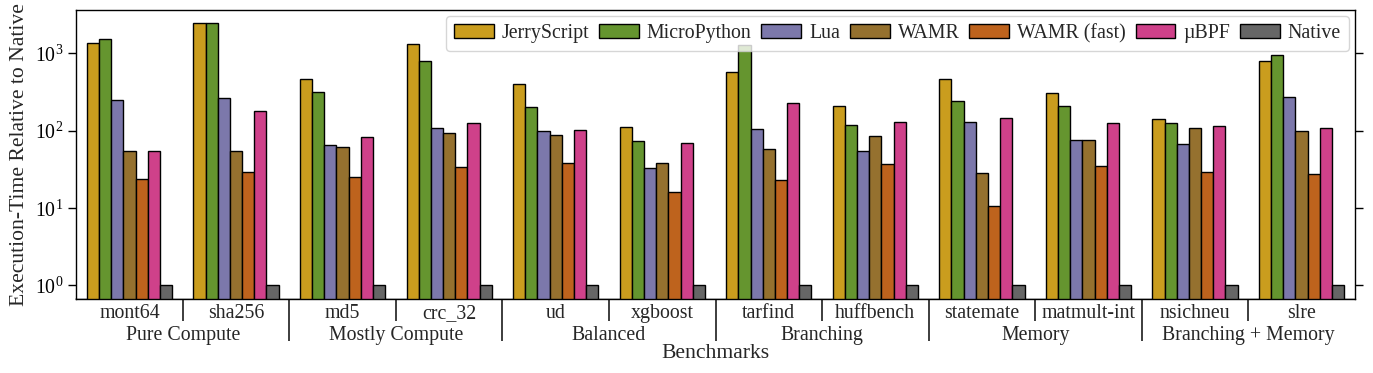

In [6]:
### FIGURE SETUP ###
sns.set_theme(style="whitegrid", font="Liberation Serif", font_scale=1.3)
fig = plt.figure(figsize=(14, 4))

### PLOTTING BARS ###
ax = sns.barplot(
    data=benchmark_df,
    x="benchmark", y="exec_rel", hue="environment",
    errorbar="sd", palette=bc_palette,
    hue_order=bc_palette.keys()
)
set_hatch(ax, set(), "")

### SECONDARY X-AXES (CATEGORY LABELS & DIVIDERS) ###
minx, maxx = ax.get_xlim()
sec = ax.secondary_xaxis(location=0)
sec.set_xticks(np.arange(minx + 1, maxx, 2), labels=b_cat)

divider_axis = ax.secondary_xaxis(location=0)
divider_axis.set_xticks(np.arange(minx + 2, maxx, 2), labels=[""] * 5)

### LEGEND ###
plt.legend(loc="upper right", ncol=7, labelspacing=0.1, handletextpad=0.4, columnspacing=0.5, borderaxespad=0.3)

### TEXT / LABELS ###
ax.set_xlabel("Benchmarks")
ax.set_ylabel("Execution-Time Relative to Native")
ax.set_title("")

### Y-AXIS FORMATTING ###
ax.set_yscale("log")
ax.set_yticks([1, 10, 100, 1000])
for tick in ax.yaxis.get_major_ticks():
    tick.tick1line.set_visible(True)
    tick.tick2line.set_visible(True)

### PADDING ###
ax.xaxis.labelpad = 15
ax.tick_params(axis="x", pad=-2)
ax.tick_params(axis="y", length=6, width=1, colors="black")
sec.tick_params(axis='x', length=16)
divider_axis.tick_params(axis='x', length=30)

### GRID & FRAME ###
ax.grid(False)
set_frame(ax)

### LAYOUT & EXPORT ###
plt.tight_layout()
plt.savefig("figures/exec_time_rel.pdf", bbox_inches="tight", format="pdf")


## Combined Load and Execution Tim

## Ranges

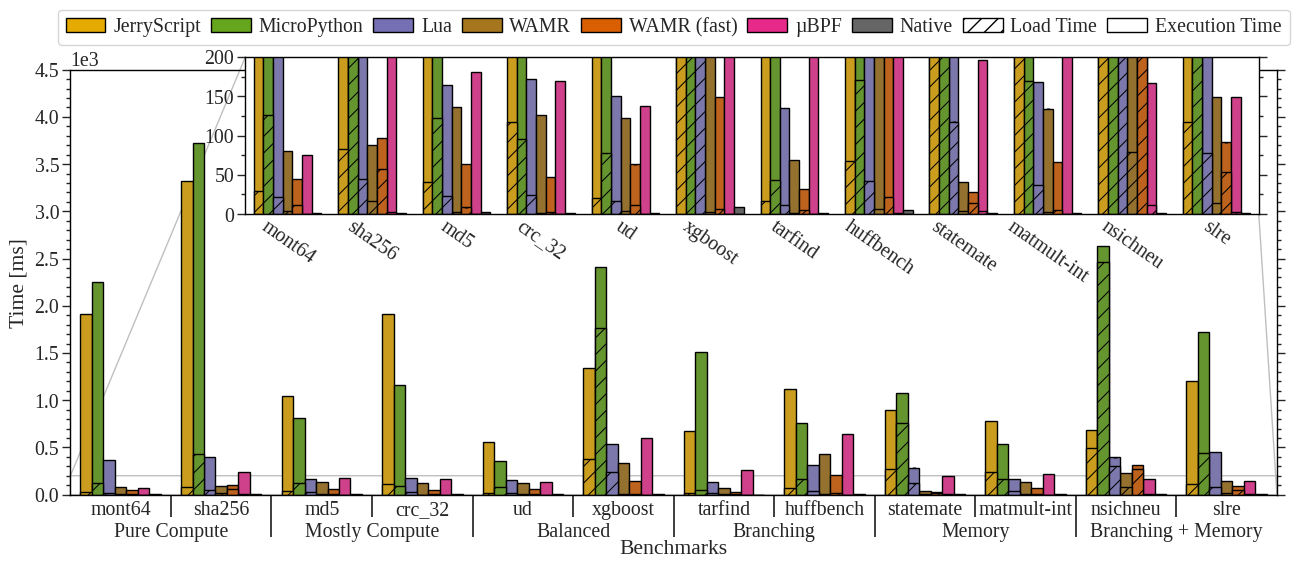

In [7]:
### FIGURE SETUP ###
sns.set_theme(style="whitegrid", font="Liberation Serif", font_scale=1.3)
fig = plt.figure(figsize=(14, 6))

### PLOTTING BARS (MAIN AXIS) ###
ax = total_bar = sns.barplot(x="benchmark", y="total", data=benchmark_df.explode("total"), hue="environment", hue_order=bc_palette.keys(), palette=bc_palette, err_kws={"color": "black", "solid_capstyle": "butt"}, errorbar="sd", capsize=0, estimator="mean")
known_patches = set()
set_hatch(ax, known_patches, "")

load_bar = sns.barplot(ax=ax, x="benchmark", y="load", data=benchmark_df.explode("load"), hue="environment", hue_order=bc_palette.keys(), palette=bc_palette, err_kws={"color": "black", "solid_capstyle": "butt"}, errorbar="sd", capsize=0, estimator="mean")
set_hatch(load_bar, known_patches, "//")

### INSET AXIS SETUP ###
x1, x2 = ax.get_xlim()
y1, y2 = 0.0, 200.0

axins = ax.inset_axes(
    [0.145, 0.66, 0.84, 0.37],
    xlim=(x1, x2), ylim=(y1, y2)
)

### PLOTTING BARS (INSET AXIS) ###
inset_upper = sns.barplot(ax=axins, x="benchmark", y="total", data=benchmark_df.explode("total"), hue="environment", hue_order=bc_palette.keys(), palette=bc_palette, err_kws={"color": "black", "solid_capstyle": "butt"}, errorbar="sd", capsize=0, estimator="mean")
known_patches = set()
set_hatch(inset_upper, known_patches, "")
inset_lower = sns.barplot(ax=axins, x="benchmark", y="load", data=benchmark_df.explode("load"), hue="environment", hue_order=bc_palette.keys(), palette=bc_palette, err_kws={"color": "black", "solid_capstyle": "butt"}, errorbar="sd", capsize=0, estimator="mean")
set_hatch(inset_lower, known_patches, "//")

### INSET ZOOM INDICATOR ###
ax.set_ylim(0, 4500)
ii = ax.indicate_inset_zoom(axins, edgecolor="grey", linewidth=1, zorder=0)

visible = {1, 2}
for i, conn in enumerate(ii.connectors):
    conn.set_visible(i in visible)

### INSET CLEANUP ###
axins.set_title("")
axins.set_xlabel("")
axins.set_ylabel("")
axins.get_legend().remove()
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

### LEGEND ###
handles= []

for language, c in bc_palette.items():
    handles.append(Patch(facecolor=c, edgecolor="black", linewidth=1.0, label=language))

handles.append(Patch(hatch="//", edgecolor="black", facecolor="none", label="Load Time"))
handles.append(Patch(hatch="", edgecolor="black", facecolor="none", label="Execution Time"))

plt.legend(handles=handles, loc="center", bbox_to_anchor=(0.5, 1.1), ncols=9, labelspacing=0.1, handletextpad=0.4, columnspacing=0.5)

### TEXT / LABELS ###
ax.set_xlabel("Benchmarks")
ax.set_ylabel("Time [ms]")
ax.set_title("")

### SECONDARY X-AXES (CATEGORY LABELS & DIVIDERS) ###
minx, maxx = ax.get_xlim()
sec = ax.secondary_xaxis(location=0)
sec.set_xticks(np.arange(minx + 1, maxx, 2), labels=b_cat)

divider_axis = ax.secondary_xaxis(location=0)
divider_axis.set_xticks(np.arange(minx + 2, maxx, 2), labels=[""] * 5)

### Y-AXIS FORMATTING ###
ax.ticklabel_format(axis='y', style='sci', scilimits=(3,3))
axins.ticklabel_format(axis='y', style="sci")
set_yticks(ax, 500, 100, True)
set_yticks(axins, 50, 25, True)

### PADDING ###
ax.xaxis.labelpad = 15
ax.tick_params(axis='x', pad=-2)
ax.tick_params(axis='y', pad=2)
sec.tick_params(axis='x', pad=4)
sec.tick_params(axis='x', length=16)
divider_axis.tick_params(axis='x', length=30)
axins.tick_params(axis='y', pad=2)
axins.tick_params(axis='x', pad=-4)
axins.tick_params(axis='x', rotation=-35)

### GRID & FRAME ###
ax.grid(False)
axins.grid(False)
set_frame(ax)
set_frame(axins)

### LAYOUT & EXPORT ###
plt.tight_layout(h_pad=0.2)
plt.savefig("figures/runtime_inset.pdf", bbox_inches="tight", format="pdf")


# Table

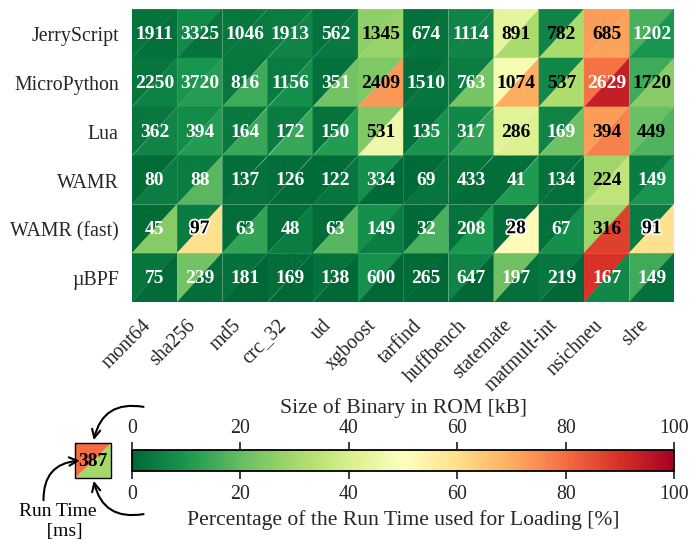

In [8]:
MAX_SIZE = 100
MAX_FRACTION = 100

### UTILITY FUNCTIONS ###
def _text_color(bg_rgba):
    return "white" if _luminance(bg_rgba) < 0.5 else "black"


def _luminance(rgba):
    return 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]


def _draw_cell(ax, x, y, color_upper, color_lower, value):
    x0, y0 = x, y
    x1, y1 = x + 1, y + 1

    ax.add_patch(Polygon([[x0, y0], [x1, y0], [x0, y1]], closed=True, color=color_upper, linewidth=0.1))
    ax.add_patch(Polygon([[x1, y0], [x1, y1], [x0, y1]], closed=True, color=color_lower, linewidth=0.1))

    avg_bg = np.array([color_upper, color_lower]).mean(axis=0)
    txt_color = _text_color(avg_bg)

    lum_upper = _luminance(color_upper)
    lum_lower = _luminance(color_lower)
    if abs(lum_upper - lum_lower) > 0.5:
        stroke_color = "black" if txt_color == "white" else "white"
        effects = [pe.withStroke(linewidth=2.5, foreground=stroke_color)]
    else:
        effects = []

    ax.text(
        x + 0.5, y + 0.5, value,
        ha="center", va="center", fontsize=14,
        color=txt_color, fontweight="bold", path_effects=effects
    )


def _draw_legend_cell(fig, cb_pos, cmap):
    cell_size = cb_pos.height * 2.0
    legend_ax = fig.add_axes([
        cb_pos.x0 - cell_size - 0.02,
        cb_pos.y0 + (cb_pos.height - cell_size) / 2,
        cell_size, cell_size
    ])

    # upper half
    legend_ax.add_patch(Polygon(
        [[0, 0], [1, 0], [1, 1]], closed=True, color=cmap(0.3), linewidth=0.1
    ))
    # lower half
    legend_ax.add_patch(Polygon(
        [[0, 0], [0, 1], [1, 1]], closed=True, color=cmap(0.8), linewidth=0.1
    ))
    # frame
    legend_ax.add_patch(Polygon(
        [[0, 0], [0, 1], [1, 1], [1, 0]], closed=True, facecolor="none", edgecolor="black", linewidth=1.0
    ))

    legend_ax.set_xlim(-0.1, 1.1)
    legend_ax.set_ylim(-0.1, 1.1)
    legend_ax.set_aspect("equal")
    legend_ax.axis("off")

    legend_ax.add_patch(FancyArrowPatch(
        posA=(0.5, 1.0), posB=(2.0, 2.0),
        connectionstyle="arc3,rad=-0.5", arrowstyle="<-",
        mutation_scale=15, color="black", linewidth=1.5, clip_on=False
    ))
    legend_ax.add_patch(FancyArrowPatch(
        posA=(0.5, 0.0), posB=(2.0, -1.0),
        connectionstyle="arc3,rad=0.5", arrowstyle="<-",
        mutation_scale=15, color="black", linewidth=1.5, clip_on=False
    ))
    legend_ax.add_patch(FancyArrowPatch(
        posA=(0.2, 0.5), posB=(-0.9, -0.7),
        connectionstyle="arc3,rad=0.5", arrowstyle="<-",
        mutation_scale=15, color="black", linewidth=1.5, clip_on=False
    ))

    legend_ax.text(
        0.5, 0.5, "387",
        ha="center", va="center", fontsize=14,
        color="black", fontweight="bold",
    )
    legend_ax.text(
        -0.5, -1.2, "Run Time\n   [ms]",
        ha="center", va="center", fontsize=14,
        color="black"
    )


def _draw_colorbar(ax, cmap, norm_bsize, norm_lfrac):
    sm = ScalarMappable(cmap=cmap, norm=norm_lfrac)
    cb = plt.colorbar(sm, ax=ax, orientation="horizontal", shrink=1.0, pad=0.32, fraction=0.046, aspect=30)
    cb.outline.set_edgecolor("black")
    cb.outline.set_linewidth(1.3)
    cb.ax.set_xlabel("Percentage of the Run Time used for Loading [%]")

    cb_secondary = cb.ax.twiny()
    cb_secondary.set_xlim(norm_bsize.vmin, norm_bsize.vmax)
    cb_secondary.set_xlabel("Size of Binary in ROM [kB]")
    cb_secondary.grid(False)
    for s in cb_secondary.spines.values():
        s.set_visible(False)

    fig = ax.get_figure()
    cb_pos = cb.ax.get_position()
    _draw_legend_cell(fig, cb_pos, cmap)


### MAIN HEATMAP GENERATOR ###

def gen_benchmark_hm(target_ax, df: pl.DataFrame, bench_order: list, env_order: list,):
    env_order = [e for e in env_order if e != "Native"]

    bench_enum = pl.Enum(bench_order)
    df_sorted = df.with_columns(pl.col("benchmark").cast(bench_enum)).sort("benchmark")

    def _pivot(val):
        wide = df_sorted.pivot(values=val, index="benchmark", on="environment", aggregate_function="first")
        wide = wide.with_columns(pl.col("benchmark").cast(bench_enum)).sort("benchmark")
        cols = ["benchmark"] + [c for c in env_order if c in wide.columns]
        return wide.select(cols)

    pivot_bsize = _pivot("b_size")
    env_cols = [c for c in env_order if c in pivot_bsize.columns]
    benchmarks = pivot_bsize["benchmark"].to_list()

    data_bsize = pivot_bsize.select(env_cols).to_numpy().astype(float).T / 1000
    data_tavg = _pivot("total_avg").select(env_cols).to_numpy().astype(float).T
    data_lfrac = _pivot("load_fraction").select(env_cols).to_numpy().astype(float).T * 100

    nrows, ncols = data_bsize.shape
    cmap = sns.color_palette("RdYlGn_r", as_cmap=True)
    norm_bsize = Normalize(vmin=0, vmax=MAX_SIZE)
    norm_lfrac = Normalize(vmin=0, vmax=MAX_FRACTION)

    ### DRAW CELLS ###
    for r in range(nrows):
        for c in range(ncols):
            _draw_cell(
                target_ax, c, r,
                color_upper=cmap(norm_bsize(data_bsize[r, c])),
                color_lower=cmap(norm_lfrac(data_lfrac[r, c])),
                value=f"{data_tavg[r, c]:.0f}",
            )

    ### AXIS CONFIGURATION ###
    target_ax.set_xlim(0, ncols)
    target_ax.set_ylim(nrows, 0)
    target_ax.set_xticks([i + 0.5 for i in range(ncols)])
    target_ax.set_xticklabels(benchmarks, rotation=45, ha="right")
    target_ax.set_yticks([i + 0.5 for i in range(nrows)])
    target_ax.set_yticklabels(env_cols)

    ### COLORBAR & LEGEND ###
    _draw_colorbar(target_ax, cmap, norm_bsize, norm_lfrac)


### DATA PREPARATION ###

mem_file = "../data/memory/section_sizes.csv"
mem_df = update_env(pl.read_csv(mem_file))
mem_df = mem_df.with_columns(pl.col("benchmark").str.replace("nettle-sha256", "sha256"))

rom_df = (
    mem_df.filter((pl.col("type") == ".text") & (pl.col("category") == "Application"))
    .group_by(["benchmark", "board", "environment"])
    .agg(b_size=pl.col("size").sum())
)

table_df = benchmark_df.join(rom_df, on=["benchmark", "environment"], how="full", coalesce=True)
table_df = table_df.filter(~(pl.col("environment") == "Native")).with_columns(pl.col("benchmark").cast(pl.Enum(b_order))).sort("benchmark")


### PLOT GENERATION ###

sns.set_theme(style="whitegrid", font="Liberation Serif", font_scale=1.3)
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

gen_benchmark_hm(ax, table_df, b_order, list(bc_palette.keys()))
set_frame(ax, color="black", linewidth=0.0)

plt.savefig("figures/load_size_hm.pdf", bbox_inches="tight", format="pdf")
